In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.enhancements.srl import annotate_dataset_with_srl
from scripts.enhancements.rbm import apply_rules_to_dataset
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "rbm"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
srl_paths = get_dataset_paths("srl")
rbm_paths = get_dataset_paths("rbm")

print("\n--- SRL Train Sample ---")
srl_df = pd.read_csv(srl_paths["train"], sep="\t", header=None)
print(f"Shape: {srl_df.shape}")
print(srl_df.head(3))


apply_rules_to_dataset(srl_paths["train"], rbm_paths["train"])  # ✅ This passes the file paths

paths = rbm_paths

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)


--- SRL Train Sample ---
Shape: (24155, 3)
                              0  \
0  A rose was helped by a dog .   
1     The sailor dusted a boy .   
2       Emma rolled a teacher .   

                                                   1  \
0  rose ( x _ 1 ) AND help . theme ( x _ 3 , x _ ...   
1  * sailor ( x _ 1 ) ; dust . agent ( x _ 2 , x ...   
2  roll . agent ( x _ 1 , Emma ) AND roll . theme...   

                                            2  
0  agent(x _ 3 ,x _ 6 ); theme(x _ 3 ,x _ 1 )  
1  agent(x _ 2 ,x _ 1 ); theme(x _ 2 ,x _ 4 )  
2   agent(x _ 1 ,Emma ); theme(x _ 1 ,x _ 3 )  

[RBM] Loaded: /notebooks/meta-semantic-research/data/srl/train.tsv
[RBM] Retained 24093 / 24155 rows
[RBM] Rejected rows: 62

[RBM] Sample rejected outputs:
 LAMBDA a . ball ( a )
 LAMBDA a . game ( a )
LAMBDA a . moose ( a )
                 Layla
                  Emma
[RBM] Rejected samples saved to: /notebooks/meta-semantic-research/data/rbm/rejected_train.tsv

[RBM] Rule violation summary:

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

[DEBUG] rbm Train Loss (Epoch 1): 1.5502
[DEBUG] rbm Dev Eval (Epoch 1):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0011
  edit_distance_avg: 96.9633
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9833
[DEBUG] rbm Train Loss (Epoch 2): 1.0301
[DEBUG] rbm Dev Eval (Epoch 2):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0013
  edit_distance_avg: 100.5600
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9667
[DEBUG] rbm Train Loss (Epoch 3): 0.7925
[DEBUG] rbm Dev Eval (Epoch 3):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0013
  edit_distance_avg: 104.1100
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9667
[DEBUG] rbm Train Loss (Epoch 4): 0.6326
[DEBUG] rbm Dev Eval (Epoch 4):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0021
  edit_distance_avg: 106.0233
  predicate_accuracy: 0.0007
  valid_logical_form_ratio: 0.8833
[DEBUG] rbm Train Loss (Epoch 5): 0.5119
[DEBUG] rbm Dev Eval (Epoch 5):


Predictions saved to: /notebooks/meta-semantic-research/predictions/rbm/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/rbm/t5-small_test_metrics.csv
[DEBUG] rbm Test Eval:
  precision: 0.0183
  recall: 0.0133
  f1: 0.0147
  bleu: 0.0096
  edit_distance_avg: 109.5933
  predicate_accuracy: 0.0151
  valid_logical_form_ratio: 0.8700


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0183,0.0133,0.0147,0.0096,109.5933,0.0151,0.8700


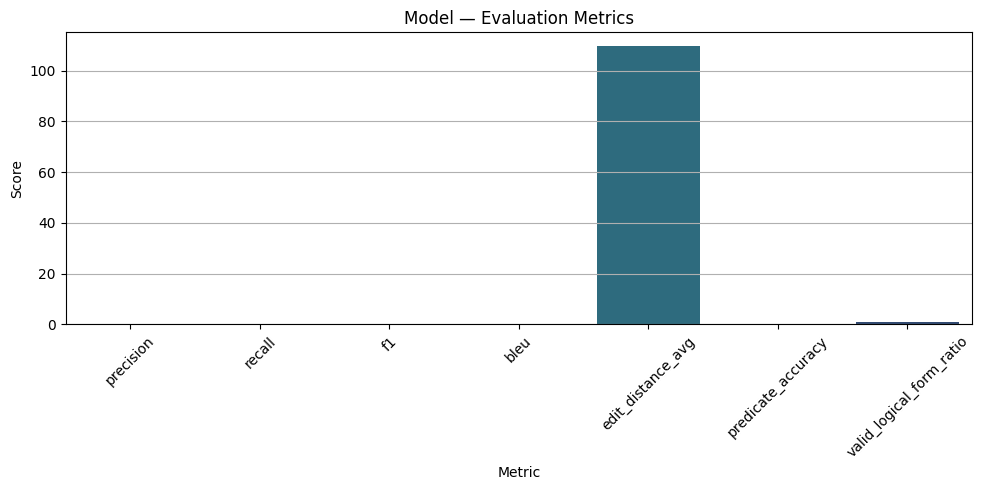

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/rbm/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/rbm/t5-small_gen_metrics.csv
[DEBUG] rbm Gen Eval:
  precision: 0.0088
  recall: 0.0046
  f1: 0.0058
  bleu: 0.0056
  edit_distance_avg: 161.9171
  predicate_accuracy: 0.0063
  valid_logical_form_ratio: 0.8676


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0088,0.0046,0.0058,0.0056,161.9171,0.0063,0.8676


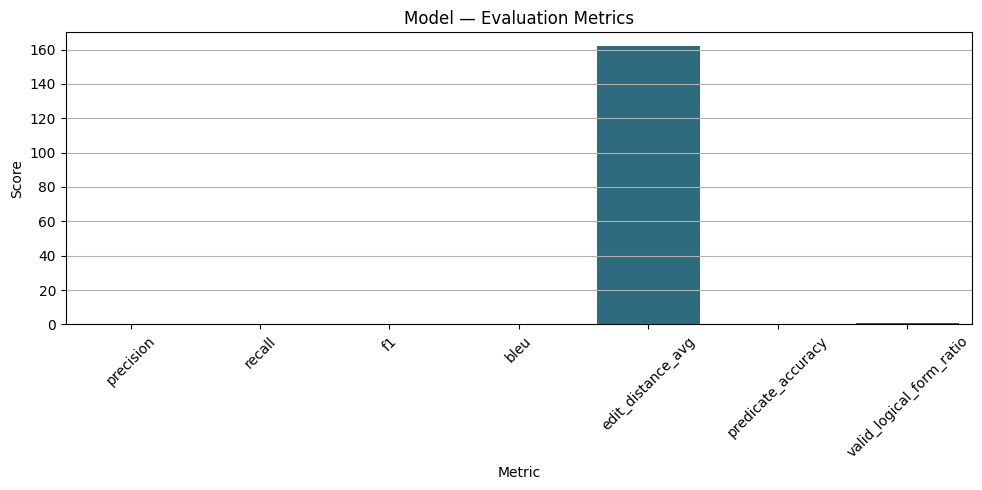

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

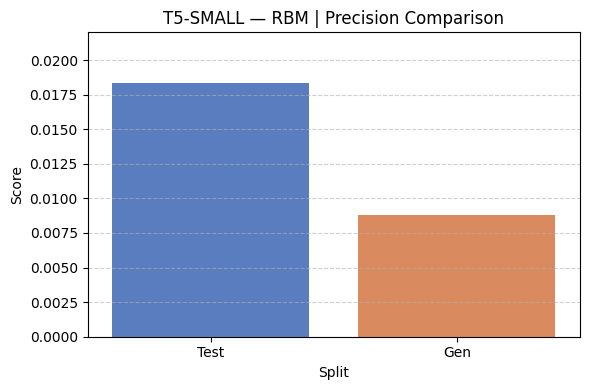

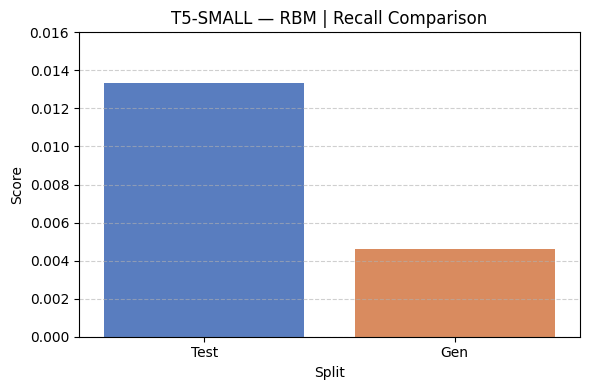

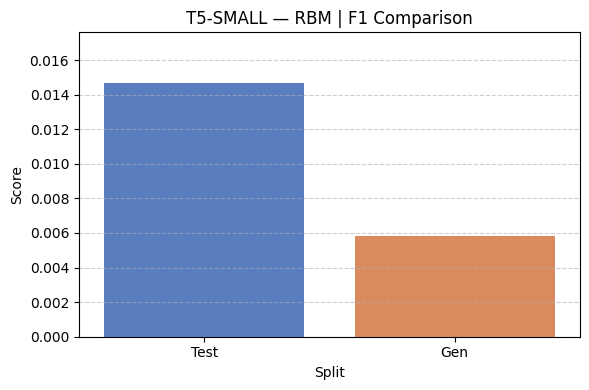

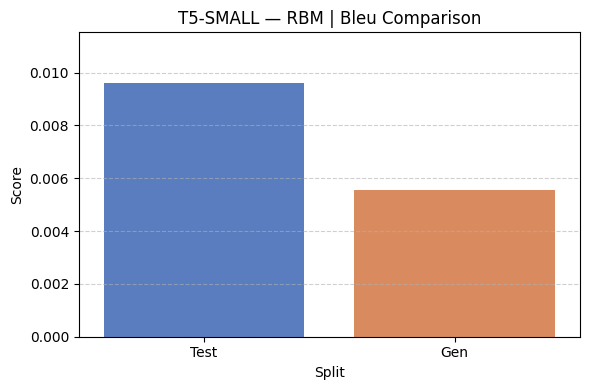

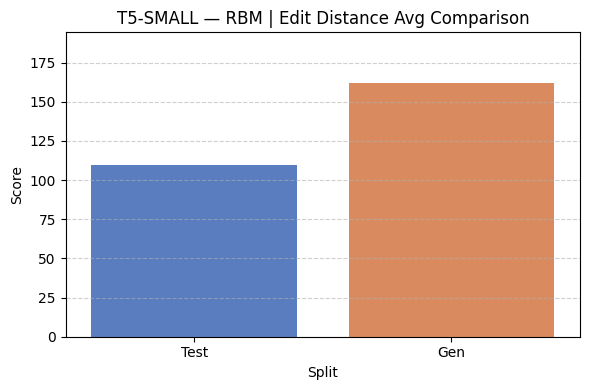

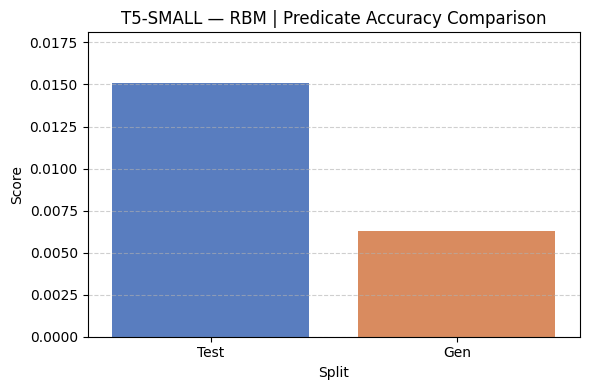

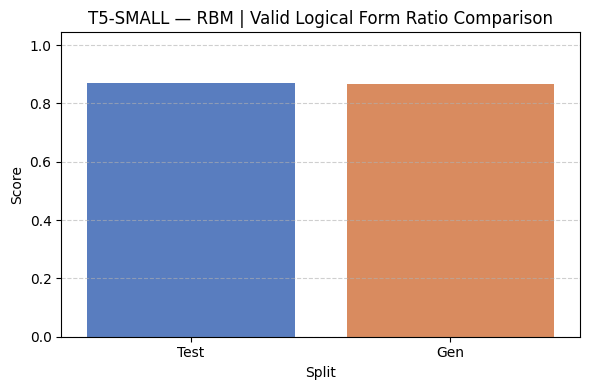

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)